<h2 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
8. Best 모델 테스트
</h2>

<h3 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
1. best.pt 불러오기
</h3>

In [8]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
%pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.4 MB/s eta 0:00:00


In [3]:
import ultralytics
print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.117


In [9]:
!ls -lh "/content/drive/MyDrive/AI_Project/wardy/ml/src/export/hazard_objects_v1_full_v1/weights"

total 214M
-rw------- 1 root root 5.3M Aug  7 07:43 best.pt
-rw------- 1 root root  21M Aug  7 05:06 epoch0.pt
-rw------- 1 root root  21M Aug  7 05:22 epoch10.pt
-rw------- 1 root root  21M Aug  7 05:38 epoch20.pt
-rw------- 1 root root  21M Aug  7 05:54 epoch30.pt
-rw------- 1 root root  21M Aug  7 06:10 epoch40.pt
-rw------- 1 root root  21M Aug  7 06:26 epoch50.pt
-rw------- 1 root root  21M Aug  7 06:42 epoch60.pt
-rw------- 1 root root  21M Aug  7 06:58 epoch70.pt
-rw------- 1 root root  21M Aug  7 07:13 epoch80.pt
-rw------- 1 root root  21M Aug  7 07:29 epoch90.pt
-rw------- 1 root root 5.3M Aug  7 07:43 last.pt


In [10]:
from pathlib import Path
from ultralytics import YOLO

BEST_MODEL = Path(
    "/content/drive/MyDrive/AI_Project/wardy/ml/src/export/"
    "hazard_objects_v1_full_v1/weights/best.pt"
)

print(BEST_MODEL)
print("best.pt 존재:", BEST_MODEL.exists())

model = YOLO(str(BEST_MODEL))
print(model.names)

/content/drive/MyDrive/AI_Project/wardy/ml/src/export/hazard_objects_v1_full_v1/weights/best.pt
best.pt 존재: True
{0: 'scissors', 1: 'knife', 2: 'cutter', 3: 'syringe'}


<h3 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
2. test 이미지 하나를 랜덤으로 돌려보기
</h3>

In [14]:
import shutil
from pathlib import Path

DRIVE_ZIP = Path(
    "/content/drive/MyDrive/AI_Project/wardy/ml/src/data/hazard_objects_v1.zip"
)

LOCAL_ZIP = Path("/content/hazard_objects_v1.zip")

print("ZIP 존재:", DRIVE_ZIP.exists())

shutil.copy2(DRIVE_ZIP, LOCAL_ZIP)
shutil.unpack_archive(LOCAL_ZIP, "/content")

ZIP 존재: True


In [16]:
!find /content -type d -path "*/images/test"


/content/object_dataset/images/test


In [19]:
TEST_DIR = Path("/content/object_dataset/images/test")
print("test 폴더 존재:", TEST_DIR.exists())

image_paths = [
    p for p in TEST_DIR.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
]

print("test 이미지 수:", len(image_paths))

test 폴더 존재: True
test 이미지 수: 569


In [23]:
from pathlib import Path
import random

TEST_DIR = Path("/content/object_dataset/images/test")

print("test 폴더 존재:", TEST_DIR.exists())

image_paths = [
    p for p in TEST_DIR.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
]

print("test 이미지 수:", len(image_paths))

# 랜덤으로 테스트 이미지 1장 선택
test_image = random.choice(image_paths)

print("테스트 이미지:", test_image.name)

results = model.predict(
    source=str(test_image),
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
)

test 폴더 존재: True
test 이미지 수: 569
테스트 이미지: syringe_v2_004192_eb1a59d7b9.jpg

image 1/1 /content/object_dataset/images/test/syringe_v2_004192_eb1a59d7b9.jpg: 640x640 3 syringes, 8.2ms
Speed: 74.3ms preprocess, 8.2ms inference, 38.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


<h3 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
3. 결과를 Colab 화면에 바로 표시
</h3>

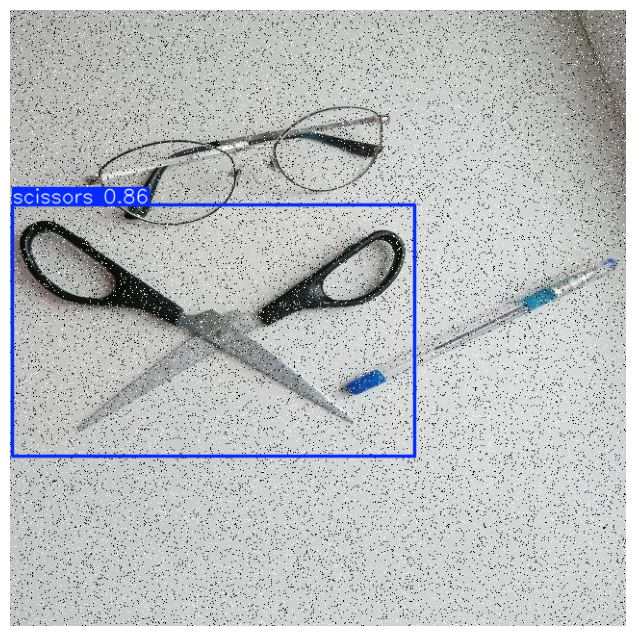

In [53]:
import matplotlib.pyplot as plt

result = results[0]

annotated = result.plot()

plt.figure(figsize=(10, 8))
plt.imshow(annotated[..., ::-1])
plt.axis("off")
plt.show()

<h3 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
4. 랜덤 이미지 10장 한꺼번에 테스트
</h3>


0: 640x640 1 scissors, 4.9ms
1: 640x640 1 cutter, 4.9ms
2: 640x640 1 scissors, 4.9ms
3: 640x640 1 syringe, 4.9ms
4: 640x640 9 scissorss, 4.9ms
5: 640x640 1 scissors, 4.9ms
6: 640x640 (no detections), 4.9ms
7: 640x640 1 knife, 4.9ms
8: 640x640 4 syringes, 4.9ms
9: 640x640 1 knife, 1 cutter, 4.9ms
Speed: 2.1ms preprocess, 4.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


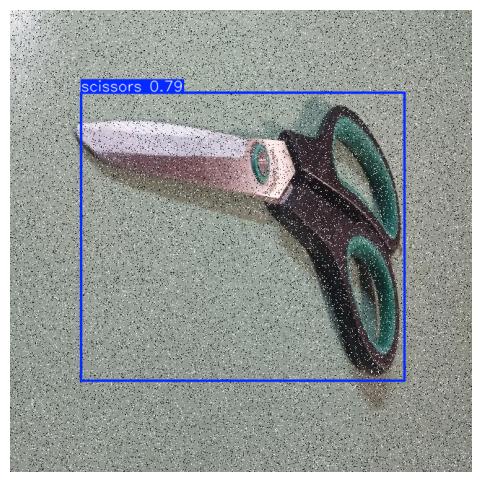

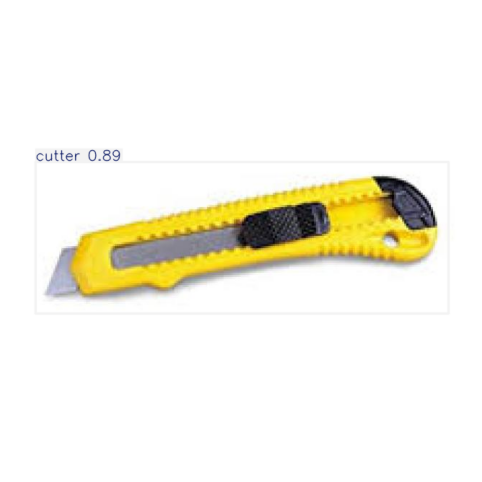

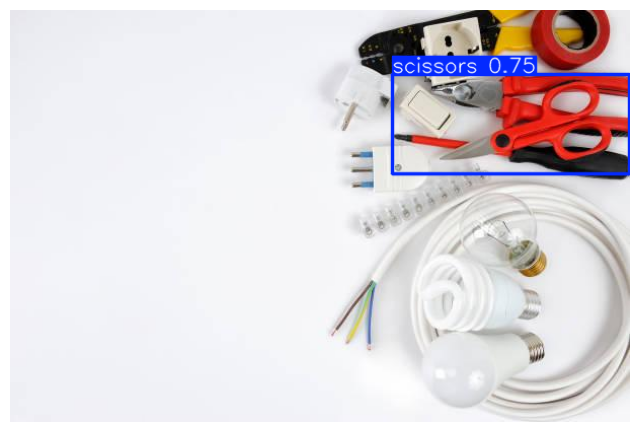

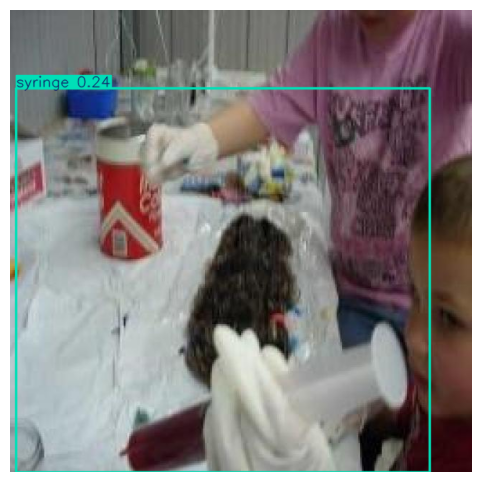

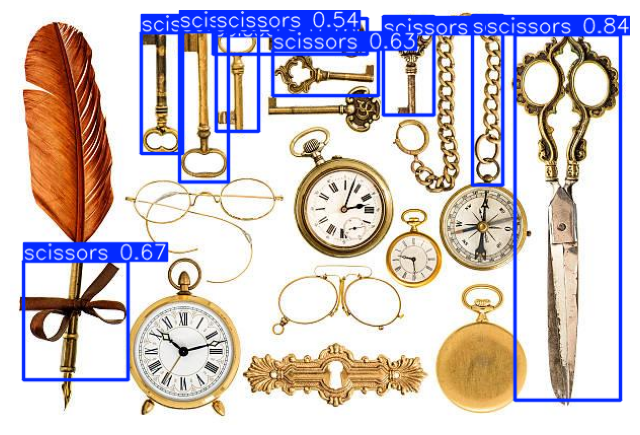

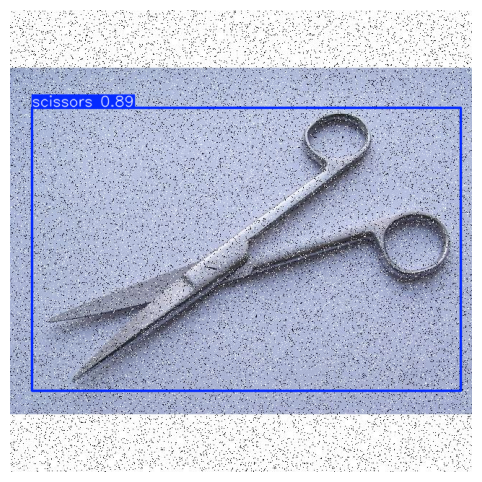

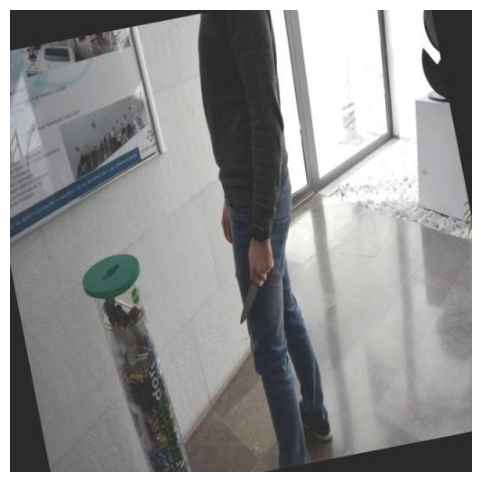

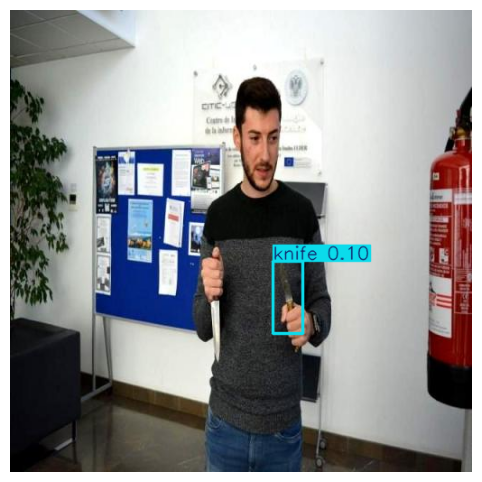

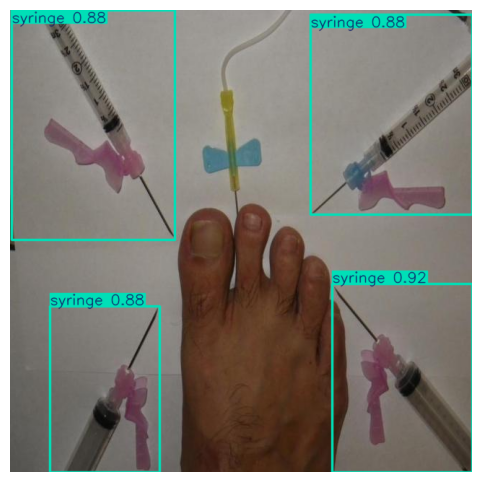

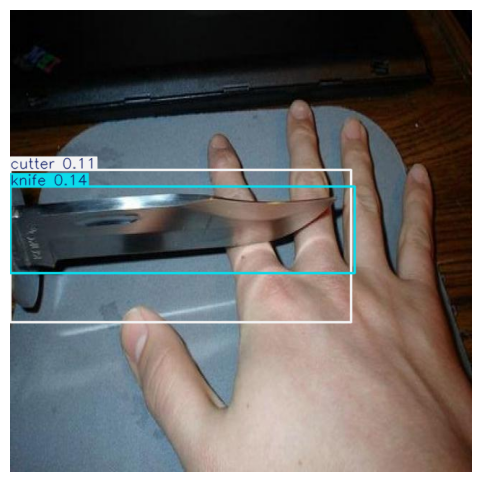

In [55]:
sample_images = random.sample(
    image_paths,
    min(10, len(image_paths))
)

results = model.predict(
    source=[str(p) for p in sample_images],
    imgsz=640,
    conf=0.1,
    iou=0.5,
    device=0,
)

for result in results:
    annotated = result.plot()

    plt.figure(figsize=(8, 6))
    plt.imshow(annotated[..., ::-1])
    plt.axis("off")
    plt.show()

<h3 style="color:#FFD866; border-left:5px solid #FFD866; padding-left:12px;">
5. 마지막으로 test set 전체 성능 측정
</h3>

In [ ]:
metrics = model.val(
    data="/content/hazard_objects_v1/data.yaml",
    split="test",
    imgsz=640,
    batch=8,
    device=0,
    plots=True,
)

print("mAP50     :", metrics.box.map50)
print("mAP50-95  :", metrics.box.map)
print("Precision :", metrics.box.mp)
print("Recall    :", metrics.box.mr)